# 06. LLM 큐레이션 + 전체 파이프라인 통합

## DL 모델만으로 부족한 것

```
유저가 입력: "요즘 피부가 건조한데 자극 없는 수분 크림 추천해줘"

DL 모델 (SASRec) 출력:
  1위: B07XK... (item_id=482)
  2위: B09AB... (item_id=1203)
  3위: B08CQ... (item_id=77)
  ...  ← 이게 왜 추천됐는지 설명 없음
       ← 자연어 쿼리의 의미를 이해하지 못함
       ← "자극 없는" 조건을 필터링하지 못함
```

## 해결: DL + LLM 2단계 파이프라인

```
자연어 쿼리
    │
    ▼ ① 쿼리 이해
  Gemini ──► UserContext {intent, preferences, constraints, keywords}
    │
    ▼ ② 후보 생성 (빠른 Recall)
  SASRec ──► Top-20 후보 (ms 단위)
    │
    ▼ ③ 재순위 + 설명 (Precision & UX)
  Gemini ──► Top-5 큐레이션 + 개인화 설명
    │
    ▼
  Streamlit 챗봇 UI
```

**왜 DL 모델로 먼저 필터하는가?**  
전체 아이템(2,216개)을 Gemini에 바로 넘기면 토큰 비용이 크고 느립니다.  
SASRec이 0.1초 안에 관련성 높은 20개로 좁혀주면 Gemini는 20개만 처리하면 됩니다.

In [12]:
import sys, os
sys.path.append('..')

from dotenv import load_dotenv
load_dotenv('../.env')

import json
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

DATA_DIR = Path('../data/processed/All_Beauty')
train_df = pd.read_parquet(DATA_DIR / 'train.parquet')
test_df  = pd.read_parquet(DATA_DIR / 'test.parquet')
meta_df  = pd.read_parquet(DATA_DIR / 'meta.parquet')
with open(DATA_DIR / 'dataset_meta.json') as f:
    meta = json.load(f)
with open(DATA_DIR / 'item2id.json') as f:
    item2id = json.load(f)
id2item = {v: k for k, v in item2id.items()}

print(f"유저 수: {meta['n_users']:,} | 아이템 수: {meta['n_items']:,}")
print(f"API Key 설정: {'✓' if os.environ.get('GEMINI_API_KEY') else '✗ (.env에 GEMINI_API_KEY 필요)'}")

유저 수: 2,087 | 아이템 수: 2,216
API Key 설정: ✓


## 1. 파이프라인 로딩

In [13]:
from llm.pipeline import RecommendationPipeline

pipeline = RecommendationPipeline.load(data_dir=DATA_DIR)
print("파이프라인 로딩 완료")
print(f"  DL 모델:    SASRec (hidden=64, layers=2, max_len=50)")
print(f"  LLM 모델:   {pipeline.curator.model}")
print(f"  아이템 수:  {pipeline.n_items:,}")

파이프라인 로딩 완료
  DL 모델:    SASRec (hidden=64, layers=2, max_len=50)
  LLM 모델:   gemini-3.5-flash
  아이템 수:  2,216


## 2. ① 쿼리 이해 — Gemini가 자연어를 구조화

`understand_query()`는 `response_schema=UserContext`를 사용해  
Gemini가 스키마를 직접 강제하므로 파싱 오류가 없습니다.

In [14]:
queries = [
    "건성 피부에 좋은 저자극 수분 크림 추천해줘",
    "향이 없고 파라벤 프리인 세럼 있어?",
    "sensitive skin moisturizer under $20",
]

for q in queries:
    ctx = pipeline.curator.understand_query(q)
    print(f"\n쿼리: {q}")
    print(f"  intent     : {ctx.intent}")
    print(f"  preferences: {ctx.preferences}")
    print(f"  constraints: {ctx.constraints}")
    print(f"  keywords   : {ctx.keywords}")
    print(f"  language   : {ctx.language}")


쿼리: 건성 피부에 좋은 저자극 수분 크림 추천해줘
  intent     : 건성 피부에 적합한 저자극 수분 크림을 추천받고 싶어합니다.
  preferences: ['건성 피부용', '저자극', '수분 공급']
  constraints: []
  keywords   : ['수분 크림', '저자극 크림', '건성 수분크림']
  language   : ko

쿼리: 향이 없고 파라벤 프리인 세럼 있어?
  intent     : 향이 없고 파라벤이 포함되지 않은 세럼을 찾고 있습니다.
  preferences: ['향이 없음 (무향)', '파라벤 프리']
  constraints: ['향료 포함 제품 제외', '파라벤 포함 제품 제외']
  keywords   : ['세럼']
  language   : ko

쿼리: sensitive skin moisturizer under $20
  intent     : Find a moisturizer suitable for sensitive skin that is priced under $20
  preferences: ['suitable for sensitive skin', 'budget under $20']
  constraints: []
  keywords   : ['moisturizer', 'sensitive skin']
  language   : en


## 3. ② SASRec 후보 생성 — 속도 확인

In [15]:
import time

USER_ID = 0
DL_TOP_K = 20

t0 = time.perf_counter()
candidates = pipeline._get_dl_candidates(USER_ID, dl_top_k=DL_TOP_K)
elapsed = time.perf_counter() - t0

print(f"SASRec 후보 생성: {elapsed*1000:.1f}ms ({DL_TOP_K}개)")
print()
print(f"{'DL순위':>6}  {'아이템 제목':50}  {'평점':>6}  {'리뷰수':>6}")
print("-" * 80)
for i, c in enumerate(candidates, 1):
    rating_str = f"{c.avg_rating:.1f}" if c.avg_rating else "  -  "
    review_str = str(c.rating_count) if c.rating_count else "-"
    print(f"{i:>6}  {c.title[:50]:50}  {rating_str:>6}  {review_str:>6}")

SASRec 후보 생성: 116.0ms (20개)

  DL순위  아이템 제목                                                  평점     리뷰수
--------------------------------------------------------------------------------
     1  ZMYCJ Water Flossers Cordless Teeth Cleaner, Water     3.5      34
     2  Facial Cleansing Brush, OLAXER IPX6 Waterproof Bod     3.6      28
     3  Beauhair Brazilian Body Wave Virgin Hair Bundles w     2.8      14
     4  Gauge Gear Ear Stretching Balm | 10 ml Jar | Pierc     4.8    3876
     5  Derma Roller PINK Kit for Face 540 Stainless Steel     3.8      10
     6  White Sands LIQUID TEXTURE, MEDIUM HOLD, Thermal S     4.3       4
     7  Joemoon Long Hair Shower Cap Women Fabric Eco Wate     4.3     435
     8  FIND BEAUTY Hair Braided Headband Plaited Hairband     4.0      29
     9  Waxing Kit Wax Warmer for Women Men Hair Removal w     3.6     234
    10  Lemon Tea Resin Earrings Cute Summer Fruit Tea Sta     4.7       2
    11  Electric Toothbrush for Adults with 12 Replaceable     4.

## 4. ③ Gemini 재순위 + 개인화 설명

In [16]:
QUERY = "Please recommend a hypoallergenic moisturizing cream that is good for oily skin."

ctx = pipeline.curator.understand_query(QUERY)
curated = pipeline.curator.curate(ctx, candidates, top_k=5)

print(f"쿼리: {QUERY}")
print(f"의도: {ctx.intent}")
print()
print(f"{'LLM순위':>7}  {'DL순위':>7}  {'순위변동':>8}  {'아이템 제목'}")
print("-" * 90)
for llm_rank, item in enumerate(curated, 1):
    delta = item.dl_rank - llm_rank
    arrow = f"▲{delta}" if delta > 0 else (f"▼{-delta}" if delta < 0 else "─")
    print(f"{llm_rank:>7}  {item.dl_rank:>7}  {arrow:>8}  {item.title[:45]}")
    print(f"         └─ {item.reason}")
    print()

쿼리: Please recommend a hypoallergenic moisturizing cream that is good for oily skin.
의도: Find a hypoallergenic moisturizing cream suitable for oily skin.

  LLM순위     DL순위      순위변동  아이템 제목
------------------------------------------------------------------------------------------
      1       12       ▲11  InfiniteAloe Gold Anti-Aging Formula - Organi
         └─ Formulated with organic aloe vera as the primary ingredient, this cream delivers deep, lightweight hydration that soothes the skin without feeling heavy or greasy, making it ideal for oily skin types.



## 5. DL 순위 vs LLM 순위 비교 시각화

Gemini가 DL 모델 순위를 얼마나 바꾸는지 확인합니다.

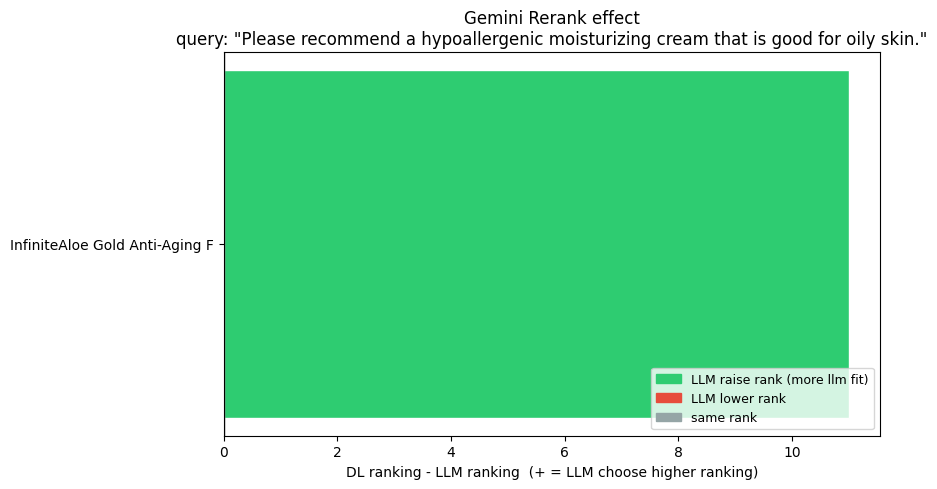

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

llm_ranks = list(range(1, len(curated) + 1))
dl_ranks  = [item.dl_rank for item in curated]
titles    = [item.title[:30] for item in curated]

colors = ['#2ecc71' if dl > llm else ('#e74c3c' if dl < llm else '#95a5a6')
          for llm, dl in zip(llm_ranks, dl_ranks)]

bars = ax.barh(titles[::-1], [d - l for d, l in zip(dl_ranks[::-1], llm_ranks[::-1])],
               color=colors[::-1], edgecolor='white', height=0.6)

ax.axvline(0, color='#333', linewidth=1)
ax.set_xlabel('DL ranking - LLM ranking  (+ = LLM choose higher ranking)')
ax.set_title(f'Gemini Rerank effect\nquery: "{QUERY}"')

up_patch   = mpatches.Patch(color='#2ecc71', label='LLM raise rank (more llm fit)')
down_patch = mpatches.Patch(color='#e74c3c', label='LLM lower rank')
same_patch = mpatches.Patch(color='#95a5a6', label='same rank')
ax.legend(handles=[up_patch, down_patch, same_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

## 6. End-to-End: 다양한 쿼리 비교

In [18]:
test_cases = [
    (0,  "건성 피부용 수분 크림"),
    (10, "향이 없고 자극 없는 세럼"),
    (50, "sensitive skin under $15"),
]

for user_id, query in test_cases:
    ctx, result = pipeline.recommend(user_id=user_id, query=query, top_k=3, dl_top_k=15)
    print(f"\n{'='*70}")
    print(f"유저 {user_id:>4} | 쿼리: {query}")
    print(f"의도: {ctx.intent}")
    if ctx.constraints:
        print(f"제외: {', '.join(ctx.constraints)}")
    print()
    for rank, item in enumerate(result, 1):
        rating = f"{item.avg_rating:.1f}★" if item.avg_rating else "-"
        print(f"  {rank}. [{rating}] {item.title[:50]}")
        print(f"     └ {item.reason}")


유저    0 | 쿼리: 건성 피부용 수분 크림
의도: 건성 피부에 적합한 수분 크림을 찾고 있습니다.

  1. [4.3★] InfiniteAloe Gold Anti-Aging Formula - Organic Alo
     └ 유기농 알로에 성분과 24시간 지속되는 수분 공급 기술이 적용되어, 건조한 피부에 깊은 보습감과 영양을 전달하고 촉촉함을 오래 유지해 줍니다.

유저   10 | 쿼리: 향이 없고 자극 없는 세럼
의도: 향이 없고 자극이 없는 순한 세럼을 찾고 있습니다.
제외: 인공 향료 제외, 자극 성분 제외

  1. [3.2★] BEPHOLAN Natural Eyelash Growth Serum and Brow Enh
     └ 자연 유래 성분으로 만들어진 순한 세럼으로, 민감한 부위에도 자극 없이 안심하고 사용할 수 있는 저자극 제품입니다.
  2. [4.4★] Karuna 7 Days of Glow - Face & Eye Mask Variety Pa
     └ 자극 없이 피부에 수분과 영양을 공급해주는 순한 에센스가 함유되어 있어 민감한 피부도 편안하게 사용할 수 있습니다.

유저   50 | 쿼리: sensitive skin under $15
의도: Find skincare products suitable for sensitive skin that cost under $15

  1. [4.7★] CELLEANSER Vegan Clean Cream 100% Vegan Ingredient
     └ This vegan cream is formulated with natural ingredients to minimize irritation and comfortably soothe sensitive skin, all while staying well under your $15 budget.
  2. [4.0★] Vitamasques Cica Green Tea Jelly Facial Cleanser G
     └ A gentle pH-b

## 7. 전체 시스템 요약

### 단계별 역할 분담

| 단계 | 구성 요소 | 입력 → 출력 | 최적화 목표 |
|------|-----------|------------|-------------|
| ① | Gemini (이해) | 자연어 → UserContext | 의도/조건 파악 |
| ② | SASRec (후보) | user_id → Top-20 item | Recall @ speed |
| ③ | Gemini (큐레이션) | Top-20 + UserContext → Top-5 + 설명 | Precision + UX |
| ④ | Streamlit UI | Top-5 → 카드 UI | 사용자 경험 |

### 각 모델의 기여

```
MF  (04)  → 협업 필터링 기초: 잠재 요인 학습
NCF (05)  → 비선형 상호작용: GMF + MLP
SASRec (06) → 시퀀셜 패턴: 취향의 변화 방향 포착  ← 최종 후보 생성 담당
Gemini (07-09) → 자연어 이해 + 개인화 설명          ← 최종 큐레이션 담당
Streamlit (08) → 대화형 UI                           ← 사용자 인터페이스
```

### 실행

```bash
uv run streamlit run ui/app.py
```